# Imports

In [20]:

from pathlib import Path
from tqdm.auto import tqdm
import os
import random
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import torch
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from huggingface_hub import hf_hub_download
import zipfile
import os
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms


# Globals

In [ ]:
#=======================
# Data Configuration
#=======================
CSV_PATH = None # used for testing purposes, now the data is loaded from the kaggle dataset.
IMAGE_ROOT = None # used for testing purposes, now the data is loaded from the kaggle dataset.
OUTPUT_DIR = "checkpoints" # Output directory for saving checkpoints of the trained models. 


#=======================
# Model Configuration
#=======================
MODEL_NAME = "resnet50"
USE_PRETRAINED = True
IMAGE_SIZE = 224
RANDOM_SEED = 20
BATCH_SIZE = 64
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0  # DO NOT CHANGE THE WORKERS VALUE. It is set to 0 to avoid issues with Windows and Jupyter notebooks.
FREEZE_BACKBONE_EPOCHS = 1  # 0 disables initial freezing.
EARLY_STOPPING_PATIENCE = 4
TRAINING_SIZE = 0.8 # Train validation split fraction. The training set is used for training the model.
VALIDATION_FRACTION = 0.2 # Train validation split fraction. The validation set is used for early stopping and hyperparameter tuning.

DETERMINISTIC = False  # Enable strict deterministic kernels when needed.
SENSITIVITY_NAMES = {}  # Optional, e.g. {0: "Low", 1: "High"}.


#=======================
# Device Configuration
#=======================
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = not DETERMINISTIC

# optimization settigs if the system detect a GPU
PIN_MEMORY = DEVICE.type == "cuda" 
USE_AMP = DEVICE.type == "cuda"


Using device: cuda
GPU: NVIDIA GeForce RTX 3070


# Utils

In [ ]:
def set_seed(seed=RANDOM_SEED, deterministic=DETERMINISTIC):
    """Set the random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)
        if deterministic:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

            
def calculate_metrics(y_true, y_pred, average="weighted"):
    """Return the common classification metrics with safe zero division."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=average, zero_division=0),
    }


def plot_training_history(history, title):
    """Plot train/validation loss, accuracy and F1 score from a model history."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    # plot loss
    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Validation")
    axes[0].set(title=f"{title} loss", xlabel="Epoch", ylabel="Loss")
    axes[0].legend()
    # plot accuracy
    axes[1].plot(epochs, history["train_accuracy"], label="Train")
    axes[1].plot(epochs, history["val_accuracy"], label="Validation")
    axes[1].set(title=f"{title} accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[1].legend()
    # plot f1
    axes[2].plot(epochs, history["val_f1"], label="Validation")
    axes[2].set(title=f"{title} F1 score", xlabel="Epoch", ylabel="F1 score")
    axes[2].legend()



    fig.tight_layout()
    plt.show()
def plot_comparing_training_history(history1, history2, title):
    """Plot train/validation loss, accuracy and F1 score from two models histories to compare them."""
    epochs = range(1, len(history1["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 4))
    # plot loss
    axes[0, 0].plot(epochs, history1["train_loss"], label="Train Model 1")
    axes[0, 0].plot(epochs, history1["val_loss"], label="Validation Model 1")
    axes[0, 0].plot(epochs, history2["train_loss"], label="Train Model 2")
    axes[0, 0].plot(epochs, history2["val_loss"], label="Validation Model 2")
    axes[0, 0].set(title=f"{title} loss", xlabel="Epoch", ylabel="Loss")
    axes[0, 0].legend()
    # plot accuracy
    axes[0, 1].plot(epochs, history1["train_accuracy"], label="Train Model 1")
    axes[0, 1].plot(epochs, history1["val_accuracy"], label="Validation Model 1")
    axes[0, 1].plot(epochs, history2["train_accuracy"], label="Train Model 2")
    axes[0, 1].plot(epochs, history2["val_accuracy"], label="Validation Model 2")
    axes[0, 1].set(title=f"{title} accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[0, 1].legend()
    # plot learning rate
    axes[1, 0].plot(epochs, history1["train_lr"], label="Train Model 1")
    axes[1, 0].plot(epochs, history1["val_lr"], label="Validation Model 1")
    axes[1, 0].plot(epochs, history2["train_lr"], label="Train Model 2")
    axes[1, 0].plot(epochs, history2["val_lr"], label="Validation Model 2")
    axes[1, 0].set(title=f"{title} learning rate", xlabel="Epoch", ylabel="Learning rate")
    axes[1, 0].legend()

    # plot per-class F1 score
    axes[1, 1].plot(epochs, history1["train_f1"], label="Train Model 1")
    axes[1, 1].plot(epochs, history1["val_f1"], label="Validation Model 1")
    axes[1, 1].plot(epochs, history2["train_f1"], label="Train Model 2")
    axes[1, 1].plot(epochs, history2["val_f1"], label="Validation Model 2")
    axes[1, 1].set(title=f"{title} F1 score", xlabel="Epoch", ylabel="F1 score")
    axes[1, 1].legend()

    fig.tight_layout()
    plt.show()


def save_checkpoint(path, model, task, class_names, epoch, best_metric):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        "task": task,
        "model_name": MODEL_NAME,
        "num_classes": len(class_names),
        "class_names": list(class_names),
        "epoch": int(epoch),
        "best_val_f1": float(best_metric),
        "model_state_dict": model.state_dict(),
    }, path)


def load_checkpoint(path, model, map_location=DEVICE):
    """Load weights while supporting PyTorch versions with/without weights_only."""
    try:
        checkpoint = torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        checkpoint = torch.load(path, map_location=map_location)
    state = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state)
    return checkpoint

def cleanup_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Data

### The following code is the download and extraction from huggingface dataset.


In [25]:
zip_path = hf_hub_download(
    repo_id="K4ru4k4i/SensiFake",
    filename="final_dataset.zip",
    repo_type="dataset"
)

extract_dir = "./sensifake"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset pronto in:", extract_dir)

path = Path(extract_dir)/"final_dataset"

KeyboardInterrupt: 

### The following code split the dataset into training and validation sets. The training set is used for training the model, while the validation set is used for early stopping and hyperparameter tuning.

In [28]:

metadata_files = list(path.rglob("sensifake_all.csv"))


if not metadata_files:
    raise FileNotFoundError(f"No metadata found in {path}")

metadata_path = metadata_files[0]
df = pd.read_csv(metadata_path)

Dataset_root = metadata_path.parent.parent
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Metadata: {metadata_path}")
print(f"Dataset shape: {df.shape}")
print("Columns:", list(df.columns))

# Detect label columns
label_candidates = ["label","real_fake_label"]
sensitivity_candidates = ["sensitivity","final_sensitivity_score"]

label_col = next((col for col in label_candidates if col in df.columns), None)
sensitivity_col = next((col for col in sensitivity_candidates if col in df.columns), None)

if label_col is None:
    raise ValueError(
        f"Could not identify the real/fake label column. Available columns: {list(df.columns)}"
    )

# Stratify using both tasks when possible
stratify_columns = [label_col]
if sensitivity_col is not None:
    stratify_columns.append(sensitivity_col)

stratify_values = df[stratify_columns].astype(str).agg("_".join, axis=1)

# Avoid stratification errors for classes containing only one sample
if stratify_values.value_counts().min() < 2:
    stratify_values = df[label_col].astype(str)

train_df, test_df = train_test_split(
    df,
    train_size=TRAINING_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=stratify_values,
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Make paths relative to the downloaded dataset root when a path column exists
image_candidates = ["image", "image_path", "filepath", "file_path", "filename", "file"]
image_col = next((col for col in image_candidates if col in df.columns), None)

if image_col is not None:
    for split_df in (train_df, test_df):
        split_df["image_path"] = split_df[image_col].apply(
            lambda path: str(path)
            if Path(str(path)).is_absolute()
            else str(path)
        )

print(f"Training samples: {len(train_df)} ({len(train_df) / len(df):.1%})")
print(f"Test samples: {len(test_df)} ({len(test_df) / len(df):.1%})")
print(f"Real/fake label column: {label_col}")
print(f"Sensitivity column: {sensitivity_col}")

Metadata: sensifake\final_dataset\metadata\sensifake_all.csv
Dataset shape: (4499, 29)
Columns: ['image_id', 'image_path', 'source_dataset', 'source_original_path', 'source_original_paths_json', 'sha256', 'source_dataset_url', 'source_dataset_license', 'source_original_id', 'source_requested_revision', 'source_resolved_revision', 'real_fake_label', 'real_fake_label_name', 'real_fake_label_provenance', 'annotation_type', 'sensitivity_label_quality', 'human_annotation_available', 'human_annotation_source', 'human_sensitivity_score', 'human_sensitivity_label', 'predicted_sensitivity_score', 'predicted_sensitivity_label', 'p_ge_1', 'p_ge_2', 'final_sensitivity_score', 'final_sensitivity_label', 'model_version', 'checkpoint_sha256', 'v3_supervision_split']
Training samples: 3599 (80.0%)
Test samples: 900 (20.0%)
Real/fake label column: real_fake_label
Sensitivity column: final_sensitivity_score


# Network

### The following code define the model architecture and the training loop. It also includes functions for evaluating the model on the validation set and saving the best model based on validation performance.

In [9]:
def create_base_model(num_classes, pretrained=USE_PRETRAINED):
    weights = models.ResNet50_Weights.DEFAULT if pretrained else None
    try:
        network = models.resnet50(weights=weights)
    except Exception as exc:
        if pretrained:
            raise RuntimeError(
                "Failed to load pretrained weights. Set USE_PRETRAINED=False to initialize randomly."
            ) from exc
        raise
    network.fc = nn.Linear(network.fc.in_features, num_classes)
    return network


class ADN(nn.Module):
    """Independent image-only real/fake classifier with two output logits."""
    def __init__(self, pretrained=USE_PRETRAINED):
        super().__init__()
        self.backbone = create_base_model(num_classes=2, pretrained=pretrained)

    def forward(self, image):
        return self.backbone(image)

class CSN(nn.Module):
    """Independent image-only sensitivity classifier."""
    def __init__(self, num_sensitivity_classes, pretrained=USE_PRETRAINED):
        super().__init__()
        if num_sensitivity_classes < 2:
            raise ValueError("At least two sensitivity classes are required for classification.")
        self.backbone = create_base_model(num_classes=num_sensitivity_classes, pretrained=pretrained)

    def forward(self, image):
        return self.backbone(image)

    

# Train

#### Training function and class definition

In [ ]:
class ImageClassificationDataset(Dataset):
    def __init__(self, frame, target_col, class_to_index, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.target_col = target_col
        self.class_to_index = class_to_index
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image_path = Dataset_root / str(row["image_path"])

        try:
            image = Image.open(image_path).convert("RGB")
        except (FileNotFoundError, UnidentifiedImageError) as exc:
            raise RuntimeError(f"Could not load image: {image_path}") from exc

        if self.transform:
            image = self.transform(image)

        label = self.class_to_index[row[self.target_col]]
        return image, torch.tensor(label, dtype=torch.long)


def _make_transforms():
    weights = models.ResNet50_Weights.DEFAULT
    preprocess = weights.transforms()

    normalize = transforms.Normalize(
        mean=preprocess.mean,
        std=preprocess.std,
    )

    train_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize,
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        normalize,
    ])

    return train_transform, eval_transform


def _split_training_data(frame, target_col):
    stratify = frame[target_col].astype(str)

    if stratify.value_counts().min() < 2:
        stratify = None

    return train_test_split(
        frame,
        test_size=VALIDATION_FRACTION,
        random_state=RANDOM_SEED,
        stratify=stratify,
        shuffle=True,
    )


def _build_loaders(frame, target_col, class_to_index):
    train_part, val_part = _split_training_data(frame, target_col)
    train_transform, eval_transform = _make_transforms()

    train_dataset = ImageClassificationDataset(
        train_part, target_col, class_to_index, train_transform
    )
    val_dataset = ImageClassificationDataset(
        val_part, target_col, class_to_index, eval_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    return train_part, val_part, train_loader, val_loader


def _class_weights(frame, target_col, class_to_index):
    labels = frame[target_col].map(class_to_index).to_numpy()
    classes = np.arange(len(class_to_index))

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=labels,
    )
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def _set_backbone_trainable(model, trainable):
    for parameter in model.backbone.parameters():
        parameter.requires_grad = trainable

    for parameter in model.backbone.fc.parameters():
        parameter.requires_grad = True


def _evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with autocast(enabled=USE_AMP):
                logits = model(images)
                loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy())

    metrics = calculate_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics


def _train_classifier(model, train_loader, val_loader, criterion, task, class_names):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        filter(lambda parameter: parameter.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scaler = GradScaler(enabled=USE_AMP)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "val_f1": [],
    }

    best_f1 = -np.inf
    best_epoch = 0
    patience_counter = 0
    checkpoint_path = Path(OUTPUT_DIR) / f"{task.lower()}_best.pt"

    for epoch in range(NUM_EPOCHS):
        if epoch == FREEZE_BACKBONE_EPOCHS:
            _set_backbone_trainable(model, True)
            optimizer = torch.optim.AdamW(
                filter(lambda parameter: parameter.requires_grad, model.parameters()),
                lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY,
            )

        model.train()
        running_loss = 0.0
        y_true, y_pred = [], []

        progress = tqdm(train_loader, desc=f"{task} epoch {epoch + 1}/{NUM_EPOCHS}")

        for images, labels in progress:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=USE_AMP):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * labels.size(0)
            y_true.extend(labels.detach().cpu().numpy())
            y_pred.extend(logits.argmax(dim=1).detach().cpu().numpy())

        train_metrics = calculate_metrics(y_true, y_pred)
        train_loss = running_loss / len(train_loader.dataset)
        val_metrics = _evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])

        print(
            f"Train loss: {train_loss:.4f}, "
            f"Train accuracy: {train_metrics['accuracy']:.4f}, "
            f"Val loss: {val_metrics['loss']:.4f}, "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_epoch = epoch + 1
            patience_counter = 0
            save_checkpoint(
                checkpoint_path,
                model,
                task,
                class_names,
                best_epoch,
                best_f1,
            )
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print("Early stopping.")
                break

    load_checkpoint(checkpoint_path, model)
    return model, history, checkpoint_path


def train_adn():
    class_values = sorted(train_df[label_col].unique())
    class_to_index = {value: index for index, value in enumerate(class_values)}
    class_names = [str(value) for value in class_values]

    _, _, train_loader, val_loader = _build_loaders(
        train_df, label_col, class_to_index
    )

    model = ADN(pretrained=USE_PRETRAINED)
    _set_backbone_trainable(model, FREEZE_BACKBONE_EPOCHS == 0)

    criterion = nn.CrossEntropyLoss(
        weight=_class_weights(train_df, label_col, class_to_index)
    )

    return _train_classifier(
        model, train_loader, val_loader, criterion, "ADN", class_names
    )


def train_csn():
    class_values = sorted(train_df[sensitivity_col].unique())
    class_to_index = {value: index for index, value in enumerate(class_values)}
    class_names = [
        SENSITIVITY_NAMES.get(value, str(value))
        for value in class_values
    ]

    _, _, train_loader, val_loader = _build_loaders(
        train_df, sensitivity_col, class_to_index
    )

    model = CSN(
        num_sensitivity_classes=len(class_values),
        pretrained=USE_PRETRAINED,
    )
    _set_backbone_trainable(model, FREEZE_BACKBONE_EPOCHS == 0)

    criterion = nn.CrossEntropyLoss(
        weight=_class_weights(train_df, sensitivity_col, class_to_index)
    )

    return _train_classifier(
        model, train_loader, val_loader, criterion, "CSN", class_names
    )

#### Training start

In [11]:
# Train both classifiers
set_seed()

adn_model, adn_history, adn_checkpoint = train_adn()

cleanup_gpu_memory()

csn_model, csn_history, csn_checkpoint = train_csn()


print(f"ADN checkpoint: {adn_checkpoint}")
print(f"CSN checkpoint: {csn_checkpoint}")

C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2868322182.py:146: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
ADN epoch 1/12:   0%|          | 0/48 [00:00<?, ?it/s]C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2868322182.py:182: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
ADN epoch 1/12: 100%|██████████| 48/48 [01:10<00:00,  1.47s/it]
C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2868322182.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Train loss: 0.6822, Train accuracy: 0.5499, Val loss: 0.6555, Val F1: 0.6574


ADN epoch 2/12:   0%|          | 0/48 [00:00<?, ?it/s]C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2868322182.py:182: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
ADN epoch 2/12: 100%|██████████| 48/48 [01:17<00:00,  1.62s/it]
C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2868322182.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Train loss: 0.4746, Train accuracy: 0.7924, Val loss: 0.4012, Val F1: 0.8093


ADN epoch 3/12:   0%|          | 0/48 [00:00<?, ?it/s]C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2868322182.py:182: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
ADN epoch 3/12: 100%|██████████| 48/48 [00:55<00:00,  1.16s/it]
C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2868322182.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


...

Train loss: 0.0449, Train accuracy: 0.9879, Val loss: 0.6369, Val F1: 0.8431


CSN epoch 7/12:   0%|          | 0/48 [00:00<?, ?it/s]C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2868322182.py:182: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
CSN epoch 7/12: 100%|██████████| 48/48 [00:56<00:00,  1.17s/it]
C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2868322182.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Train loss: 0.0255, Train accuracy: 0.9944, Val loss: 0.6896, Val F1: 0.8439


CSN epoch 8/12:   0%|          | 0/48 [00:00<?, ?it/s]C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2868322182.py:182: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
CSN epoch 8/12: 100%|██████████| 48/48 [00:56<00:00,  1.17s/it]
C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2868322182.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Train loss: 0.0171, Train accuracy: 0.9961, Val loss: 0.6940, Val F1: 0.8442
Early stopping.
ADN checkpoint: checkpoints\adn_best.pt
CSN checkpoint: checkpoints\csn_best.pt


#### Little script to see witch parameters are saved in the training loop

In [17]:
for name, history in [("ADN", adn_history), ("CSN", csn_history)]:
    print(f"\n{name}")
    for key, values in history.items():
        print(f"  {key}: {len(values)} values")


ADN
  train_loss: 12 values
  val_loss: 12 values
  train_accuracy: 12 values
  val_accuracy: 12 values
  val_f1: 12 values

CSN
  train_loss: 8 values
  val_loss: 8 values
  train_accuracy: 8 values
  val_accuracy: 8 values
  val_f1: 8 values


### Code for plotting the models metrics

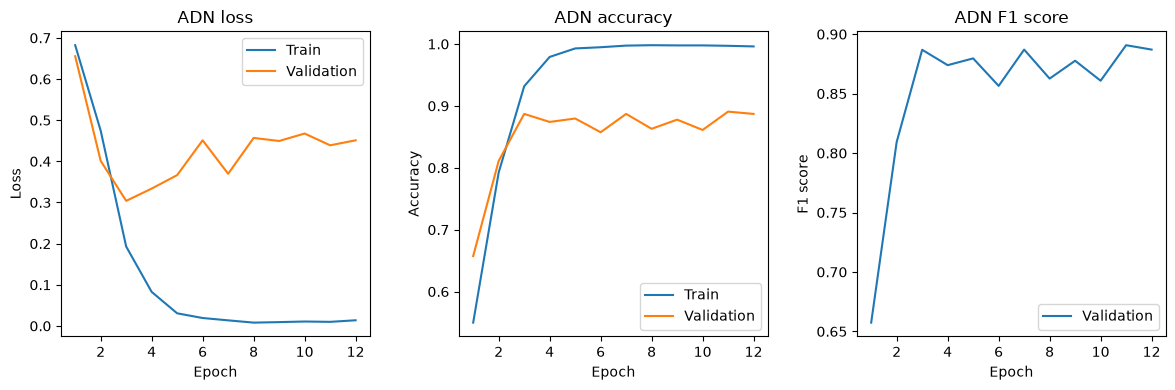

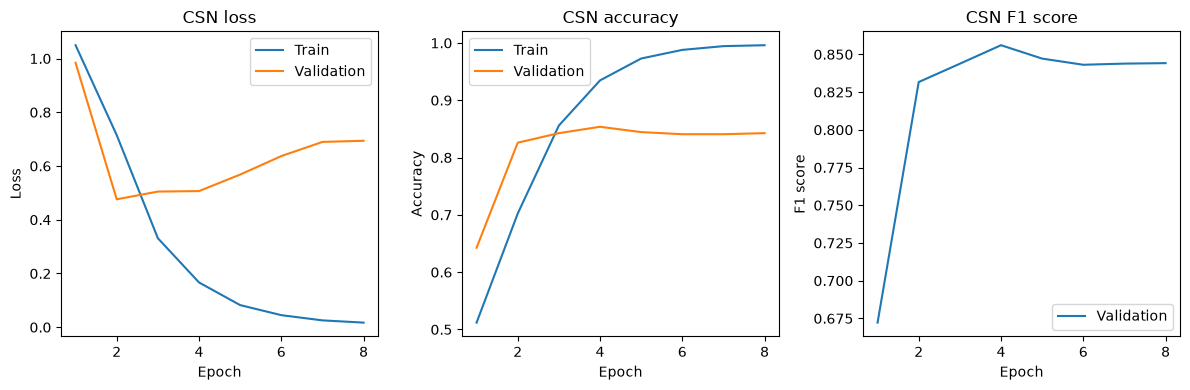

ValueError: x and y must have same first dimension, but have shapes (12,) and (8,)

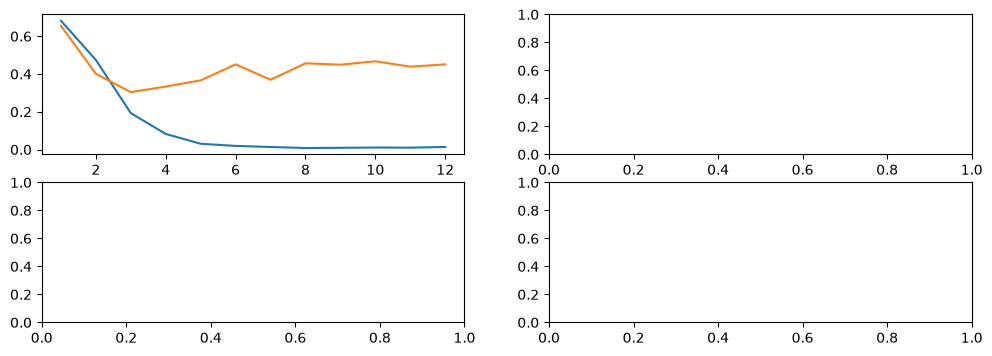

In [19]:
plot_training_history(adn_history, "ADN")
plot_training_history(csn_history, "CSN")

plot_comparing_training_history(adn_history, csn_history, "ADN vs CSN")


# Test

In [30]:
image_path = Path(r"C:/Users/lberr/Desktop/ComputerVision/test_immagine.jpg")

In [29]:
adn_checkpoint = Path(OUTPUT_DIR) / "adn_best.pt"
csn_checkpoint = Path(OUTPUT_DIR) / "csn_best.pt"

if not adn_checkpoint.exists():
    raise FileNotFoundError(f"ADN checkpoint not found: {adn_checkpoint}")

if not csn_checkpoint.exists():
    raise FileNotFoundError(f"CSN checkpoint not found: {csn_checkpoint}")

# Read checkpoint metadata
adn_metadata = torch.load(adn_checkpoint, map_location=DEVICE, weights_only=False)
csn_metadata = torch.load(csn_checkpoint, map_location=DEVICE, weights_only=False)

# Recreate models without downloading pretrained weights
adn_model = ADN(pretrained=False).to(DEVICE)
csn_model = CSN(
    num_sensitivity_classes=csn_metadata["num_classes"],
    pretrained=False,
).to(DEVICE)

# Load trained weights
load_checkpoint(adn_checkpoint, adn_model)
load_checkpoint(csn_checkpoint, csn_model)

adn_model.eval()
csn_model.eval()

print(f"Loaded ADN checkpoint: {adn_checkpoint}")
print(f"ADN classes: {adn_metadata['class_names']}")
print(f"Loaded CSN checkpoint: {csn_checkpoint}")
print(f"CSN classes: {csn_metadata['class_names']}")

Loaded ADN checkpoint: checkpoints\adn_best.pt
ADN classes: ['0', '1']
Loaded CSN checkpoint: checkpoints\csn_best.pt
CSN classes: ['0', '1', '2']


In [31]:

if not image_path.is_absolute():
    image_path = Dataset_root / image_path

if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path}")

_, eval_transform = _make_transforms()
image = Image.open(image_path).convert("RGB")
image_tensor = eval_transform(image).unsqueeze(0).to(DEVICE)

adn_checkpoint_data = load_checkpoint(adn_checkpoint, adn_model)
csn_checkpoint_data = load_checkpoint(csn_checkpoint, csn_model)

adn_model.eval()
csn_model.eval()

with torch.inference_mode():
    with autocast(enabled=USE_AMP):
        adn_logits = adn_model(image_tensor)
        csn_logits = csn_model(image_tensor)

adn_probabilities = torch.softmax(adn_logits, dim=1)[0].cpu().numpy()
csn_probabilities = torch.softmax(csn_logits, dim=1)[0].cpu().numpy()

adn_index = int(adn_probabilities.argmax())
csn_index = int(csn_probabilities.argmax())

adn_names = adn_checkpoint_data["class_names"]
csn_names = csn_checkpoint_data["class_names"]

adn_prediction = adn_names[adn_index]
csn_prediction = csn_names[csn_index]

adn_confidence = adn_probabilities[adn_index]
csn_confidence = csn_probabilities[csn_index]

print(f"Image: {image_path}")
print(
    f"ADN prediction: {adn_prediction} "
    f"(confidence: {adn_confidence:.2%})"
)
print("ADN probabilities:")
for name, probability in zip(adn_names, adn_probabilities):
    print(f"  {name}: {probability:.2%}")

print(
    f"\nCSN prediction: {csn_prediction} "
    f"(confidence: {csn_confidence:.2%})"
)
print("CSN probabilities:")
for name, probability in zip(csn_names, csn_probabilities):
    print(f"  {name}: {probability:.2%}")

Image: C:\Users\lberr\Desktop\ComputerVision\test_immagine.jpg
ADN prediction: 0 (confidence: 99.46%)
ADN probabilities:
  0: 99.46%
  1: 0.52%

CSN prediction: 2 (confidence: 97.61%)
CSN probabilities:
  0: 2.16%
  1: 0.22%
  2: 97.61%


C:\Users\lberr\AppData\Local\Temp\ipykernel_16816\2382130002.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


In [32]:
W_H=0.9
W_M=0.5
W_L=0.3

G_FAKE=1
G_REAL=0.9

high_value=csn_probabilities[2]
medium_value=csn_probabilities[1]
low_value=csn_probabilities[0]


p_fake=adn_probabilities[1]
p_real=adn_probabilities[0]

#high value * coefficient_high + medium value * coefficient_medium + low value * coefficient_low

sensitivity_value=high_value*W_H+medium_value*W_M+low_value*W_L

#|p0 - p1|
confidence=abs(p_fake-p_real)

if p_fake>p_real:
    res=confidence*G_FAKE*sensitivity_value
else:
    res=confidence*G_REAL*sensitivity_value

print (f"\nSensitivity value: {sensitivity_value}")
print (f"\nConfidence: {confidence}")
print (f"\nResult: {res}")




Sensitivity value: 0.8857421875

Confidence: 0.9892578125

Result: 0.78857421875
